<a href="https://colab.research.google.com/github/Urpia-S/Olist_E-commerce_Analytic-SQL-Python/blob/main/notebooks/03_entregas_satisfacao_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 - Entregas, atrasos e satisfacao

Aqui eu junto tempo de entrega e reviews para entender onde atraso pesa mais na experiencia do cliente.

In [1]:
from pathlib import Path
import sqlite3
import urllib.request
import zipfile

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 120)

PROJECT_DIR = Path.cwd()
DB_ZIP_URL = "https://github.com/Urpia-S/Olist_E-commerce_Analytic-SQL-Python/releases/download/data-v1/olist_colab.sqlite.zip"
OUTPUT_DIR = PROJECT_DIR / "outputs_colab"
DB_PATH = PROJECT_DIR / "olist_colab.sqlite"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def baixar_banco_da_release():
    zip_path = PROJECT_DIR / "olist_colab.sqlite.zip"
    urllib.request.urlretrieve(DB_ZIP_URL, zip_path)

    with zipfile.ZipFile(zip_path) as archive:
        archive.extractall(PROJECT_DIR)

    print("Banco extraido em:", DB_PATH)


if not DB_PATH.exists():
    baixar_banco_da_release()

conn = sqlite3.connect(DB_PATH)


def consulta(sql):
    return pd.read_sql_query(sql, conn)


def salvar_consulta(sql, arquivo):
    df = consulta(sql)
    destino = OUTPUT_DIR / arquivo
    df.to_csv(destino, index=False)
    print(f"Arquivo salvo: {destino}")
    return df


def grafico_barras(df, x, y, titulo, rotacao=0, top=None):
    dados = df.head(top) if top else df
    ax = dados.plot(kind="bar", x=x, y=y, legend=False, figsize=(10, 4))
    ax.set_title(titulo)
    ax.set_xlabel("")
    ax.set_ylabel(y)
    plt.xticks(rotation=rotacao, ha="right" if rotacao else "center")
    plt.tight_layout()
    plt.show()


consulta("""
-- Objetos disponiveis no banco preparado.
SELECT
    type AS tipo,
    name AS objeto
FROM sqlite_master
WHERE type IN ('table', 'view')
ORDER BY type, name
LIMIT 20;
""")

Banco extraido em: /content/olist_colab.sqlite


,tipo,objeto
0,table,core_customers
1,table,core_geolocation_zip_city
2,table,core_order_items
3,table,core_order_payments
4,table,core_order_reviews
5,table,core_orders
6,table,core_product_category_translation
7,table,core_products
8,table,core_sellers
9,table,stg_customers


## 1. Entregas e atrasos

Calculo indicadores por estado e por categoria usando a view de entrega.

In [2]:
indicadores_entrega_estado = salvar_consulta("""
-- Indicadores de entrega por estado do cliente.
SELECT
    customer_state AS estado_cliente,
    COUNT(*) AS pedidos,
    SUM(CASE WHEN order_delivered_customer_date IS NOT NULL THEN 1 ELSE 0 END) AS pedidos_entregues,
    ROUND(AVG(dias_entrega), 2) AS media_dias_entrega,
    ROUND(AVG(dias_ate_aprovacao), 2) AS media_dias_ate_aprovacao,
    ROUND(AVG(dias_ate_transportadora), 2) AS media_dias_ate_transportadora,
    ROUND(AVG(dias_transporte_cliente), 2) AS media_dias_transporte_cliente,
    ROUND(AVG(dias_atraso), 2) AS media_dias_atraso,
    ROUND(
        100.0 * SUM(CASE WHEN entrega_atrasada = 1 THEN 1 ELSE 0 END)
        / NULLIF(SUM(CASE WHEN order_delivered_customer_date IS NOT NULL THEN 1 ELSE 0 END), 0),
        2
    ) AS percentual_atraso
FROM vw_order_delivery
GROUP BY customer_state
ORDER BY percentual_atraso DESC, pedidos DESC;
""", "indicadores_entrega_estado.csv")

indicadores_entrega_estado.head(10)

Arquivo salvo: /content/outputs_colab/indicadores_entrega_estado.csv


,estado_cliente,pedidos,pedidos_entregues,media_dias_entrega,media_dias_ate_aprovacao,media_dias_ate_transportadora,media_dias_transporte_cliente,media_dias_atraso,percentual_atraso
0,AL,413,397,24.50,0.57,2.85,21.07,2.04,21.41
1,MA,747,717,21.51,0.69,2.90,17.94,1.83,17.43
2,SE,350,335,21.46,0.54,3.11,17.89,2.47,15.22
3,PI,495,476,19.39,0.52,2.65,16.25,1.85,13.87
4,CE,1336,1279,21.20,0.52,2.81,17.89,2.09,13.76
5,RR,46,41,29.34,1.26,3.24,25.61,4.44,12.20
6,BA,3380,3256,19.28,0.57,2.72,15.99,1.46,12.16
7,RJ,12852,12353,15.24,0.46,2.85,11.94,1.64,12.10
8,PA,975,946,23.73,0.60,2.87,20.26,1.44,11.21
9,ES,2033,1995,15.72,0.52,2.84,12.35,1.21,10.73


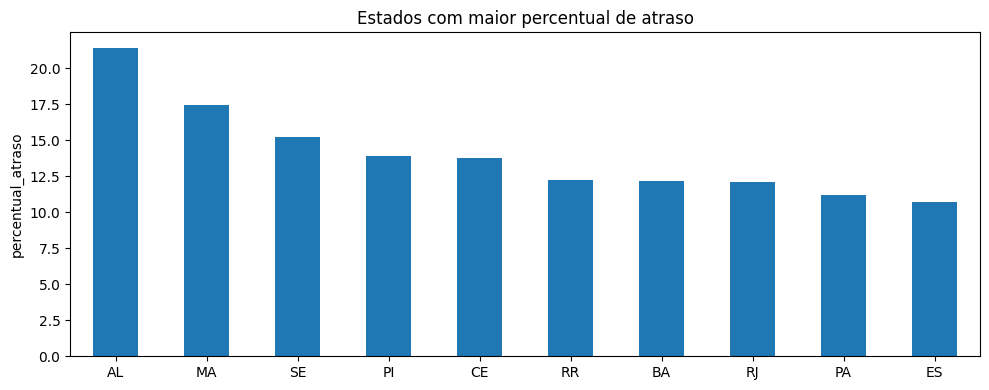

In [3]:
grafico_barras(indicadores_entrega_estado, "estado_cliente", "percentual_atraso", "Estados com maior percentual de atraso", rotacao=0, top=10)

In [4]:
atraso_por_categoria = salvar_consulta("""
-- Atraso por categoria, filtrando categorias com volume minimo.
SELECT
    i.categoria_ingles,
    COUNT(DISTINCT d.order_id) AS pedidos,
    ROUND(AVG(d.dias_entrega), 2) AS media_dias_entrega,
    ROUND(AVG(d.dias_atraso), 2) AS media_dias_atraso,
    ROUND(
        100.0 * COUNT(DISTINCT CASE WHEN d.entrega_atrasada = 1 THEN d.order_id END)
        / NULLIF(COUNT(DISTINCT CASE WHEN d.order_delivered_customer_date IS NOT NULL THEN d.order_id END), 0),
        2
    ) AS percentual_atraso
FROM vw_order_delivery d
JOIN vw_order_items_enriched i ON i.order_id = d.order_id
GROUP BY i.categoria_ingles
HAVING COUNT(DISTINCT d.order_id) >= 30
ORDER BY percentual_atraso DESC, pedidos DESC;
""", "atraso_por_categoria.csv")

atraso_por_categoria.head()

Arquivo salvo: /content/outputs_colab/atraso_por_categoria.csv


,categoria_ingles,pedidos,media_dias_entrega,media_dias_atraso,percentual_atraso
0,furniture_mattress_and_upholstery,38,14.41,2.05,13.51
1,audio,350,13.27,0.96,11.78
2,home_confort,397,13.46,1.21,9.44
3,fashion_underwear_beach,121,13.61,0.79,9.40
4,books_technical,260,10.58,0.52,8.20


In [5]:

atraso_por_vendedor = salvar_consulta("""
-- Atraso por vendedor, considerando pedidos entregues e vendedores com volume minimo.
WITH vendedor_pedido AS (
    SELECT DISTINCT
        seller_id,
        order_id
    FROM vw_order_items_enriched
)
SELECT
    vp.seller_id,
    COUNT(DISTINCT d.order_id) AS pedidos,
    ROUND(AVG(d.dias_atraso), 2) AS media_dias_atraso,
    ROUND(
        100.0 * COUNT(DISTINCT CASE WHEN d.entrega_atrasada = 1 THEN d.order_id END)
        / NULLIF(COUNT(DISTINCT CASE WHEN d.order_delivered_customer_date IS NOT NULL THEN d.order_id END), 0),
        2
    ) AS percentual_atraso
FROM vendedor_pedido vp
JOIN vw_order_delivery d ON d.order_id = vp.order_id
GROUP BY vp.seller_id
HAVING COUNT(DISTINCT d.order_id) >= 20
ORDER BY percentual_atraso DESC, pedidos DESC;
""", "atraso_por_vendedor.csv")

atraso_por_vendedor.head(10)


Arquivo salvo: /content/outputs_colab/atraso_por_vendedor.csv


,seller_id,pedidos,media_dias_atraso,percentual_atraso
0,4342d4b2ba6b161468c63a7e7cfce593,20,3.00,50.00
1,821fb029fc6e495ca4f08a35d51e53a5,28,2.58,33.33
2,ede0c03645598cdfc63ca8237acbe73d,46,3.35,32.56
3,ad781527c93d00d89a11eecd9dcad7c1,44,3.97,31.58
4,b19f3ca2ea475913750f25a5c37c8d8f,24,3.21,31.58
5,54965bbe3e4f07ae045b90b0b8541f52,78,8.40,30.14
6,054694fa03fe82cec4b7551487331d74,21,10.50,30.00
7,7f152321c60a266edc53af1925ef96c1,20,5.15,30.00
8,f76a3b1349b6df1ee875d1f3fa4340f0,24,2.63,29.17
9,2a1348e9addc1af5aaa619b1a3679d6b,52,12.15,27.08


## 2. Satisfacao

Depois comparo notas de review com status de entrega, estado e categoria.

In [6]:
distribuicao_reviews = salvar_consulta("""
-- Distribuicao das notas dos reviews.
SELECT
    review_score,
    CASE
        WHEN review_score IN (1, 2) THEN 'baixa'
        WHEN review_score = 3 THEN 'neutra'
        WHEN review_score IN (4, 5) THEN 'alta'
    END AS classe_satisfacao,
    COUNT(*) AS reviews
FROM core_order_reviews
GROUP BY review_score
ORDER BY review_score;
""", "distribuicao_reviews.csv")

satisfacao_por_status_entrega = salvar_consulta("""
-- Comparo nota media e reviews baixos por status de entrega.
SELECT
    CASE
        WHEN d.entrega_atrasada = 1 THEN 'atrasada'
        WHEN d.entrega_atrasada = 0 THEN 'no_prazo'
        ELSE 'sem_entrega_confirmada'
    END AS status_entrega,
    COUNT(DISTINCT d.order_id) AS pedidos,
    ROUND(AVG(r.nota_media_review), 2) AS nota_media,
    ROUND(100.0 * SUM(r.reviews_baixos) / NULLIF(SUM(r.quantidade_reviews), 0), 2) AS percentual_reviews_baixos
FROM vw_order_delivery d
LEFT JOIN vw_reviews_por_pedido r ON r.order_id = d.order_id
GROUP BY status_entrega
ORDER BY nota_media;
""", "satisfacao_por_status_entrega.csv")

display(distribuicao_reviews)
display(satisfacao_por_status_entrega)

Arquivo salvo: /content/outputs_colab/distribuicao_reviews.csv
Arquivo salvo: /content/outputs_colab/satisfacao_por_status_entrega.csv


,review_score,classe_satisfacao,reviews
0,1,baixa,11424
1,2,baixa,3151
2,3,neutra,8179
3,4,alta,19142
4,5,alta,57328


,status_entrega,pedidos,nota_media,percentual_reviews_baixos
0,sem_entrega_confirmada,2965,1.75,77.66
1,atrasada,6535,2.27,62.40
2,no_prazo,89941,4.29,9.28


In [7]:

satisfacao_por_estado = salvar_consulta("""
-- Satisfacao por estado do cliente.
SELECT
    d.customer_state AS estado_cliente,
    COUNT(DISTINCT d.order_id) AS pedidos_avaliados,
    ROUND(AVG(r.nota_media_review), 2) AS nota_media,
    ROUND(100.0 * SUM(r.reviews_baixos) / NULLIF(SUM(r.quantidade_reviews), 0), 2) AS percentual_reviews_baixos
FROM vw_order_delivery d
JOIN vw_reviews_por_pedido r ON r.order_id = d.order_id
GROUP BY d.customer_state
ORDER BY nota_media ASC, percentual_reviews_baixos DESC;
""", "satisfacao_por_estado.csv")

satisfacao_por_estado.head(10)


Arquivo salvo: /content/outputs_colab/satisfacao_por_estado.csv


,estado_cliente,pedidos_avaliados,nota_media,percentual_reviews_baixos
0,RR,46,3.61,23.91
1,AL,410,3.76,23.91
2,MA,742,3.76,21.72
3,SE,349,3.81,21.78
4,CE,1326,3.85,19.86
5,PA,962,3.85,19.63
6,BA,3340,3.86,18.89
7,RJ,12687,3.88,20.74
8,PI,490,3.92,18.33
9,PE,1635,4.01,16.65


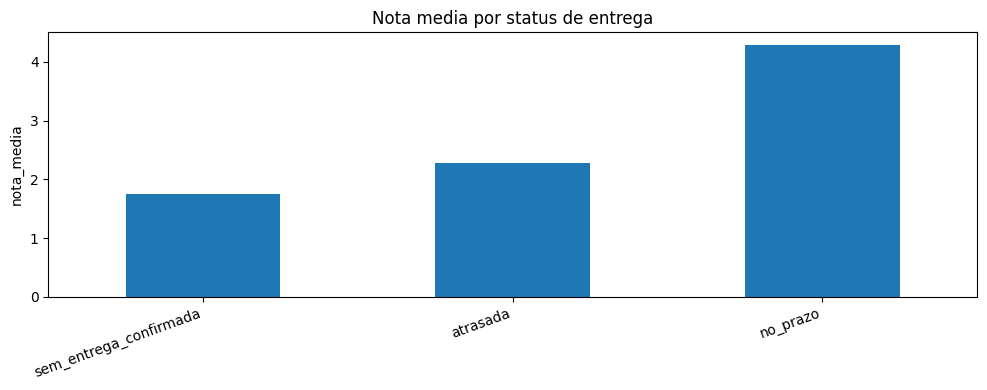

In [8]:
grafico_barras(satisfacao_por_status_entrega, "status_entrega", "nota_media", "Nota media por status de entrega", rotacao=20)

In [9]:
satisfacao_por_categoria = salvar_consulta("""
-- Satisfacao por categoria com volume minimo de pedidos avaliados.
SELECT
    i.categoria_ingles,
    COUNT(DISTINCT i.order_id) AS pedidos_avaliados,
    ROUND(AVG(r.nota_media_review), 2) AS nota_media,
    ROUND(100.0 * SUM(r.reviews_baixos) / NULLIF(SUM(r.quantidade_reviews), 0), 2) AS percentual_reviews_baixos
FROM vw_order_items_enriched i
JOIN vw_reviews_por_pedido r ON r.order_id = i.order_id
GROUP BY i.categoria_ingles
HAVING COUNT(DISTINCT i.order_id) >= 30
ORDER BY percentual_reviews_baixos DESC, pedidos_avaliados DESC;
""", "satisfacao_por_categoria.csv")

satisfacao_por_categoria.head(10)

Arquivo salvo: /content/outputs_colab/satisfacao_por_categoria.csv


,categoria_ingles,pedidos_avaliados,nota_media,percentual_reviews_baixos
0,fashion_male_clothing,111,3.64,28.24
1,office_furniture,1263,3.49,26.08
2,fixed_telephony,214,3.68,25.57
3,party_supplies,39,3.77,23.26
4,unknown,1439,3.84,22.09
5,audio,347,3.83,21.88
6,furniture_mattress_and_upholstery,38,3.82,21.05
7,home_confort,395,3.83,20.23
8,construction_tools_safety,166,3.84,20.21
9,furniture_decor,6398,3.91,19.46
